### Import packages

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import math
import numpy as np
import camb
import csv
from camb import model, initialpower
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

Using CAMB 1.5.9 installed at /mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/CMBFeatureNet/CAMB/camb


### Read the data

In [2]:
#Planck TT data
data_Planck = np.loadtxt('./experimental_data/COM_PowerSpect_CMB-TT-full_R3.01.txt')
ls_Planck_TT = data_Planck[:, 0]
dl_Planck_TT = data_Planck[:, 1]
sdl_Planck_TT1 = data_Planck[:, 2]
sdl_Planck_TT2 = data_Planck[:, 3]
round_ls_Pl_TT = np.round(ls_Planck_TT)

#Planck TE data
data_Planck = np.loadtxt('./experimental_data/COM_PowerSpect_CMB-TE-full_R3.01.txt')
ls_Planck_TE = data_Planck[:, 0]
dl_Planck_TE = data_Planck[:, 1]
sdl_Planck_TE1 = data_Planck[:, 2]
sdl_Planck_TE2 = data_Planck[:, 3]
round_ls_Pl_TE = np.round(ls_Planck_TE)

#Planck EE data
data_Planck = np.loadtxt('./experimental_data/COM_PowerSpect_CMB-EE-full_R3.01.txt')
ls_Planck_EE = data_Planck[:, 0]
dl_Planck_EE = data_Planck[:, 1]
sdl_Planck_EE1 = data_Planck[:, 2]
sdl_Planck_EE2 = data_Planck[:, 3]
round_ls_Pl_EE = np.round(ls_Planck_EE)

### Functions: symmetrize errors, Dls <=> Cls

In [3]:
#Symmetrize errors:
def symm(splus,sminus):
    return (splus + sminus)/2 

#Converting the c_ls^TT to Dls
def Dls(l,CTT):
    Dl = [l[i]*(l[i]+1)*CTT[i]/(2*math.pi) for i in range(len(l))]
    return Dl

#Conerting Dls to the c_ls^TT
def sCls(l,sDlTT):
    sClTT = [(2*math.pi)/l[i]*(l[i]+1)*sDlTT[i] for i in range(len(l))]
    return sClTT

In [4]:
#Simmetrized error bars
sdl_Planck_TT = symm(sdl_Planck_TT1, sdl_Planck_TT2)
sdl_Planck_TE = symm(sdl_Planck_TE1, sdl_Planck_TE2)
sdl_Planck_EE = symm(sdl_Planck_EE1, sdl_Planck_EE2)

### Create Covariance Matrix (for symmetrized errors)

In [5]:
#TT Planck errors:
cov_matx_dltt_symm = np.diag(sdl_Planck_TT**2) #[micro K^2]^2

#TE Planck errors:
cov_matx_dlte_symm = np.diag(sdl_Planck_TE**2) #[micro K^2]^2

#EE Planck errors:
cov_matx_dlee_symm = np.diag(sdl_Planck_EE**2) #[micro K^2]^2

In [6]:
from CMBFeatureNet import generate_camb_power_spectra
Power_spectra = generate_camb_power_spectra(67.4, 0.02237, 0.1200, 0.06, 0, tau=0.0544,  
                    As=2.1e-9, ns=0.9649, halofit_version='mead', lmax=2507)

<class 'functions.simulate_data.CMBPowerSpectra'>


In [7]:
from CMBFeatureNet import add_noise_spectrum
seed0 = 314100

dlstt_symmetrized = add_noise_spectrum(Power_spectra.tt, cov_matx_dltt_symm, seed0)
dlste_symmetrized = add_noise_spectrum(Power_spectra.te, cov_matx_dlte_symm, seed0)
dlsee_symmetrized = add_noise_spectrum(Power_spectra.ee, cov_matx_dlee_symm, seed0)

dlstt = Power_spectra.tt[:len(round_ls_Pl_TT)]
dlste = Power_spectra.te[:len(round_ls_Pl_TE)]
dlsee = Power_spectra.ee[:len(round_ls_Pl_EE)]

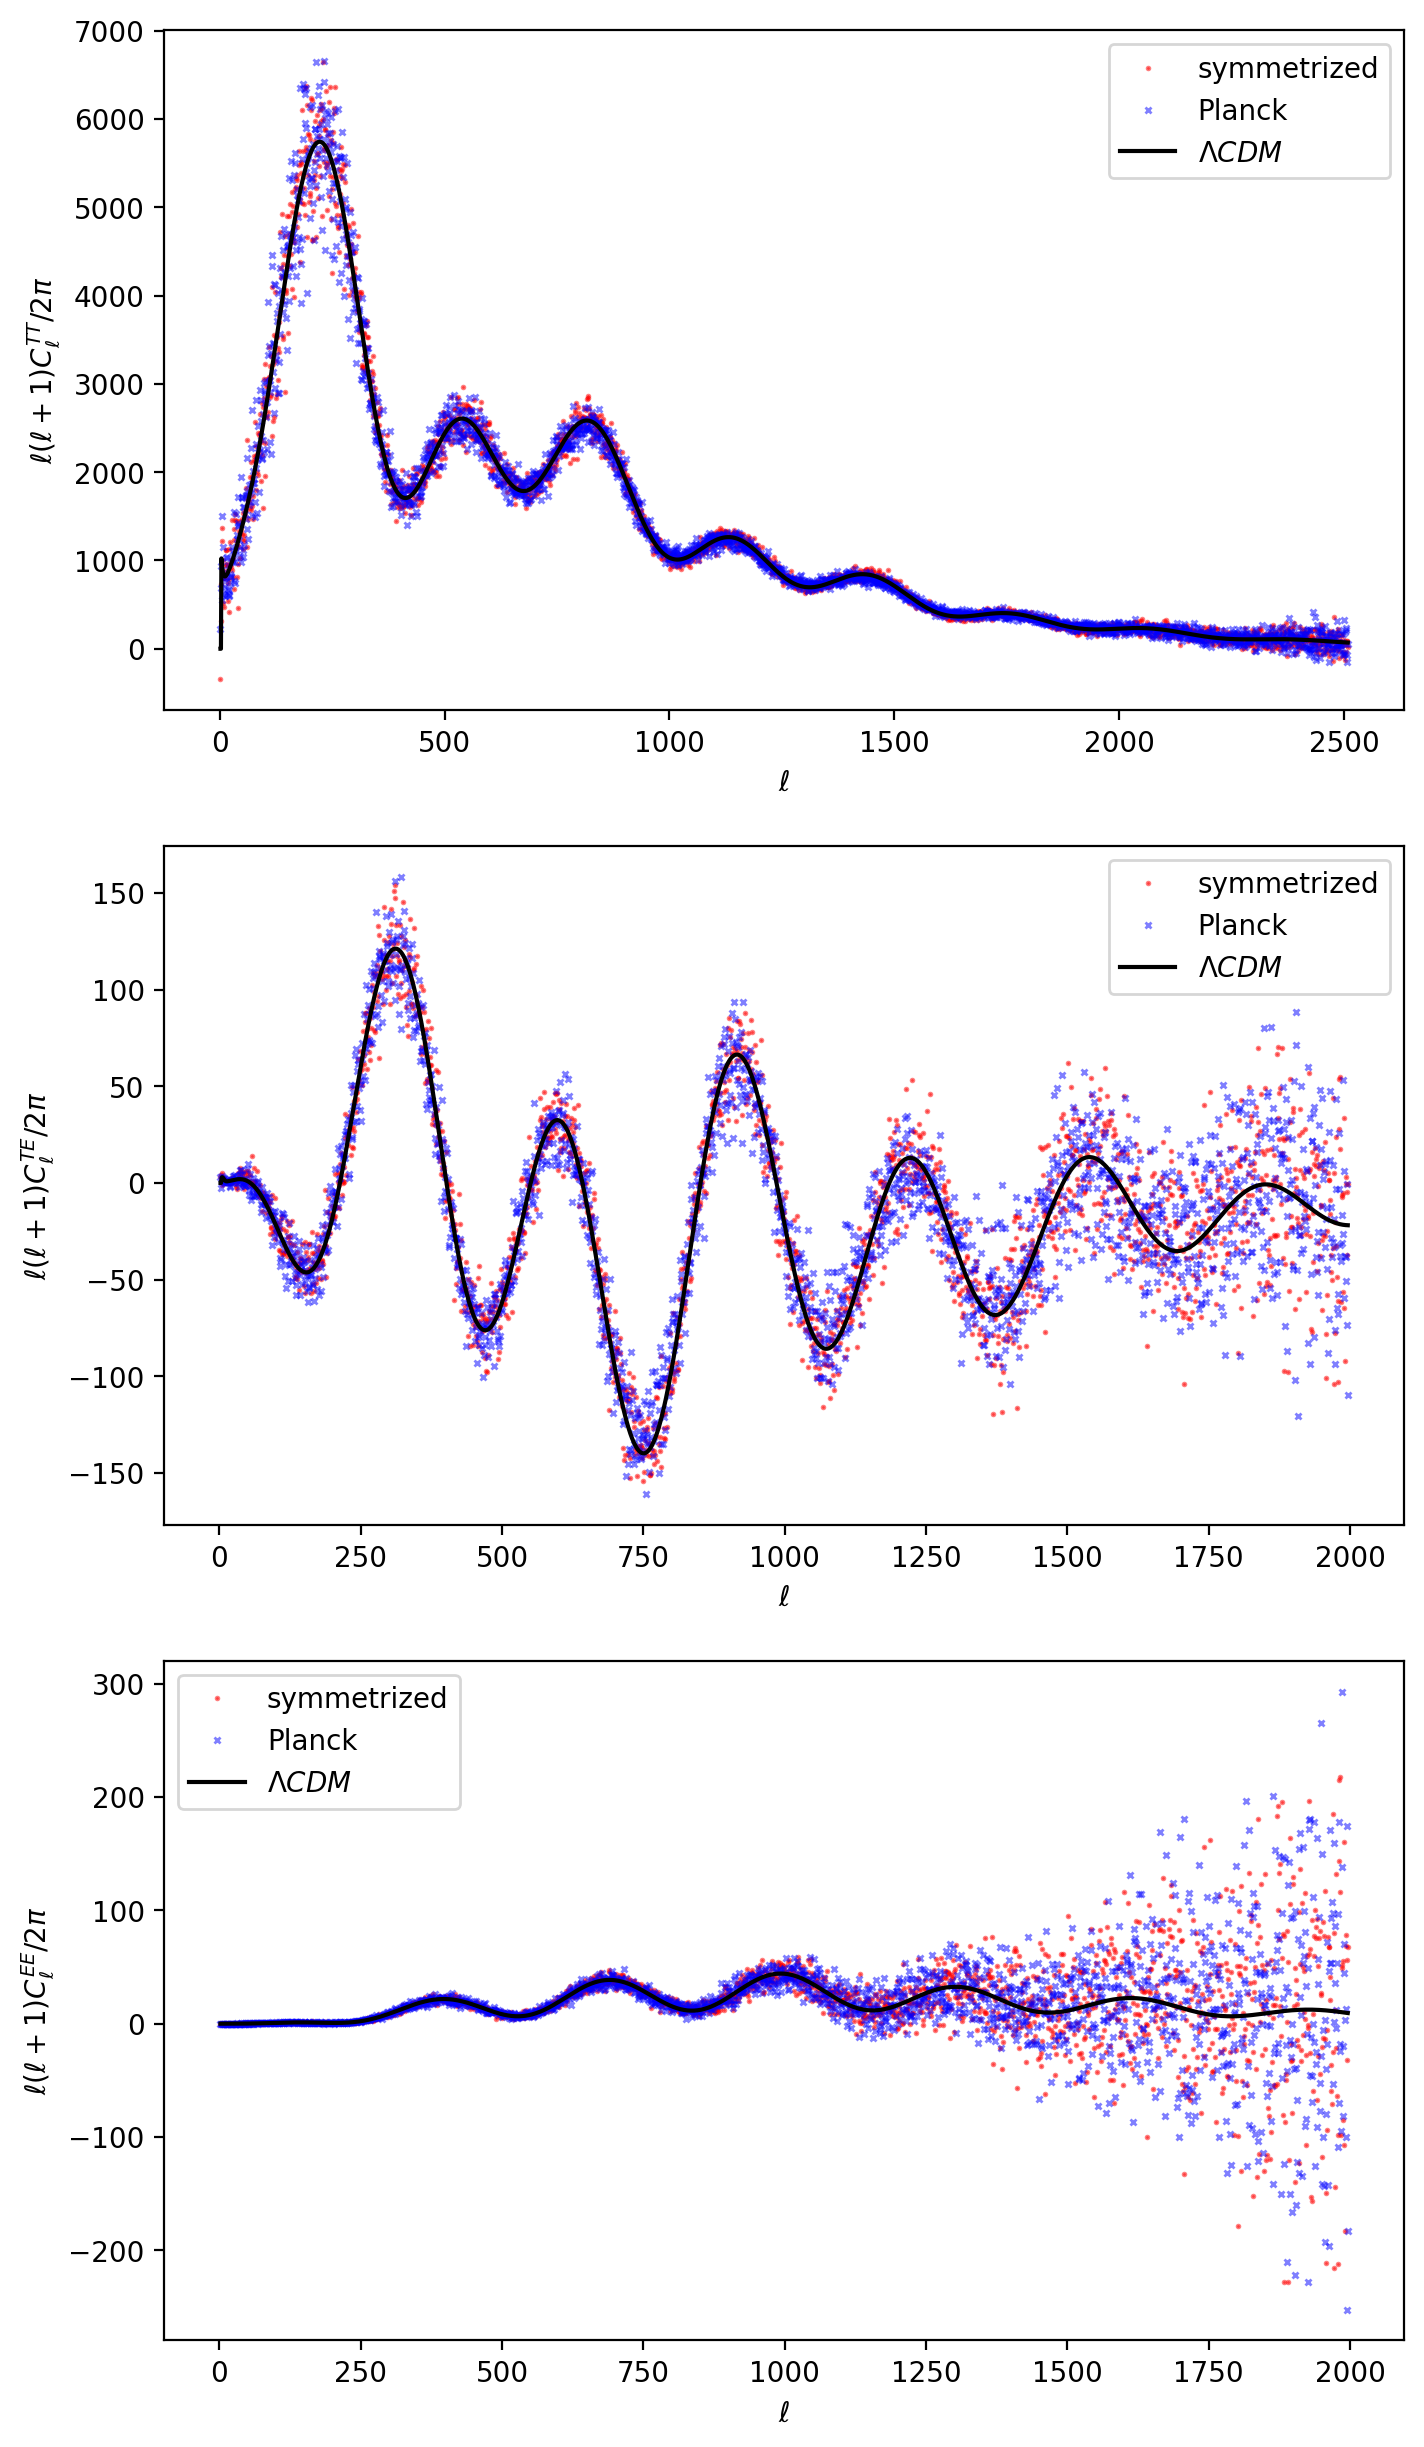

In [8]:
fig, ax = plt.subplots(3,1, figsize = (8,15))

ax[0].plot(round_ls_Pl_TT,dlstt_symmetrized, marker='o', color='red', label='symmetrized', linestyle='None', markersize=1, alpha = 0.5)
ax[0].plot(round_ls_Pl_TT,dl_Planck_TT, marker='x', color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.5)
ax[0].plot(round_ls_Pl_TT, dlstt, color='black', label='$\Lambda CDM$', linestyle='-')
ax[0].set_xlabel('$\ell$')
ax[0].set_ylabel('$\ell(\ell+1)C_{\ell}^{TT}/2\pi$')
ax[0].legend()

ax[1].plot(round_ls_Pl_TE,dlste_symmetrized, marker='o', color='red', label='symmetrized', linestyle='None', markersize=1, alpha = 0.5)
ax[1].plot(round_ls_Pl_TE,dl_Planck_TE, marker='x', color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.5)
ax[1].plot(round_ls_Pl_TE, dlste, color='black', label='$\Lambda CDM$', linestyle='-')
ax[1].set_xlabel('$\ell$')
ax[1].set_ylabel('$\ell(\ell+1)C_{\ell}^{TE}/2\pi$')
ax[1].legend()

ax[2].plot(round_ls_Pl_EE,dlsee_symmetrized, marker='o', color='red', label='symmetrized', linestyle='None', markersize=1, alpha = 0.5)
ax[2].plot(round_ls_Pl_EE,dl_Planck_EE, marker='x', color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.5)
ax[2].plot(round_ls_Pl_EE, dlsee, color='black', label='$\Lambda CDM$', linestyle='-')
ax[2].set_xlabel('$\ell$')
ax[2].set_ylabel('$\ell(\ell+1)C_{\ell}^{EE}/2\pi$')
ax[2].legend()

# MCMC covariance matrix plots

In [9]:
#Read Covariance matrix
cov_matx_dltt_mcmc = np.loadtxt('./simulated_data/dlstt_cov_matx(mcmc).csv', delimiter=",")

In [10]:
dlstt_mcmc = add_noise_spectrum(Power_spectra.tt, cov_matx_dltt_mcmc, seed0)

(-10.0, 2515.0)

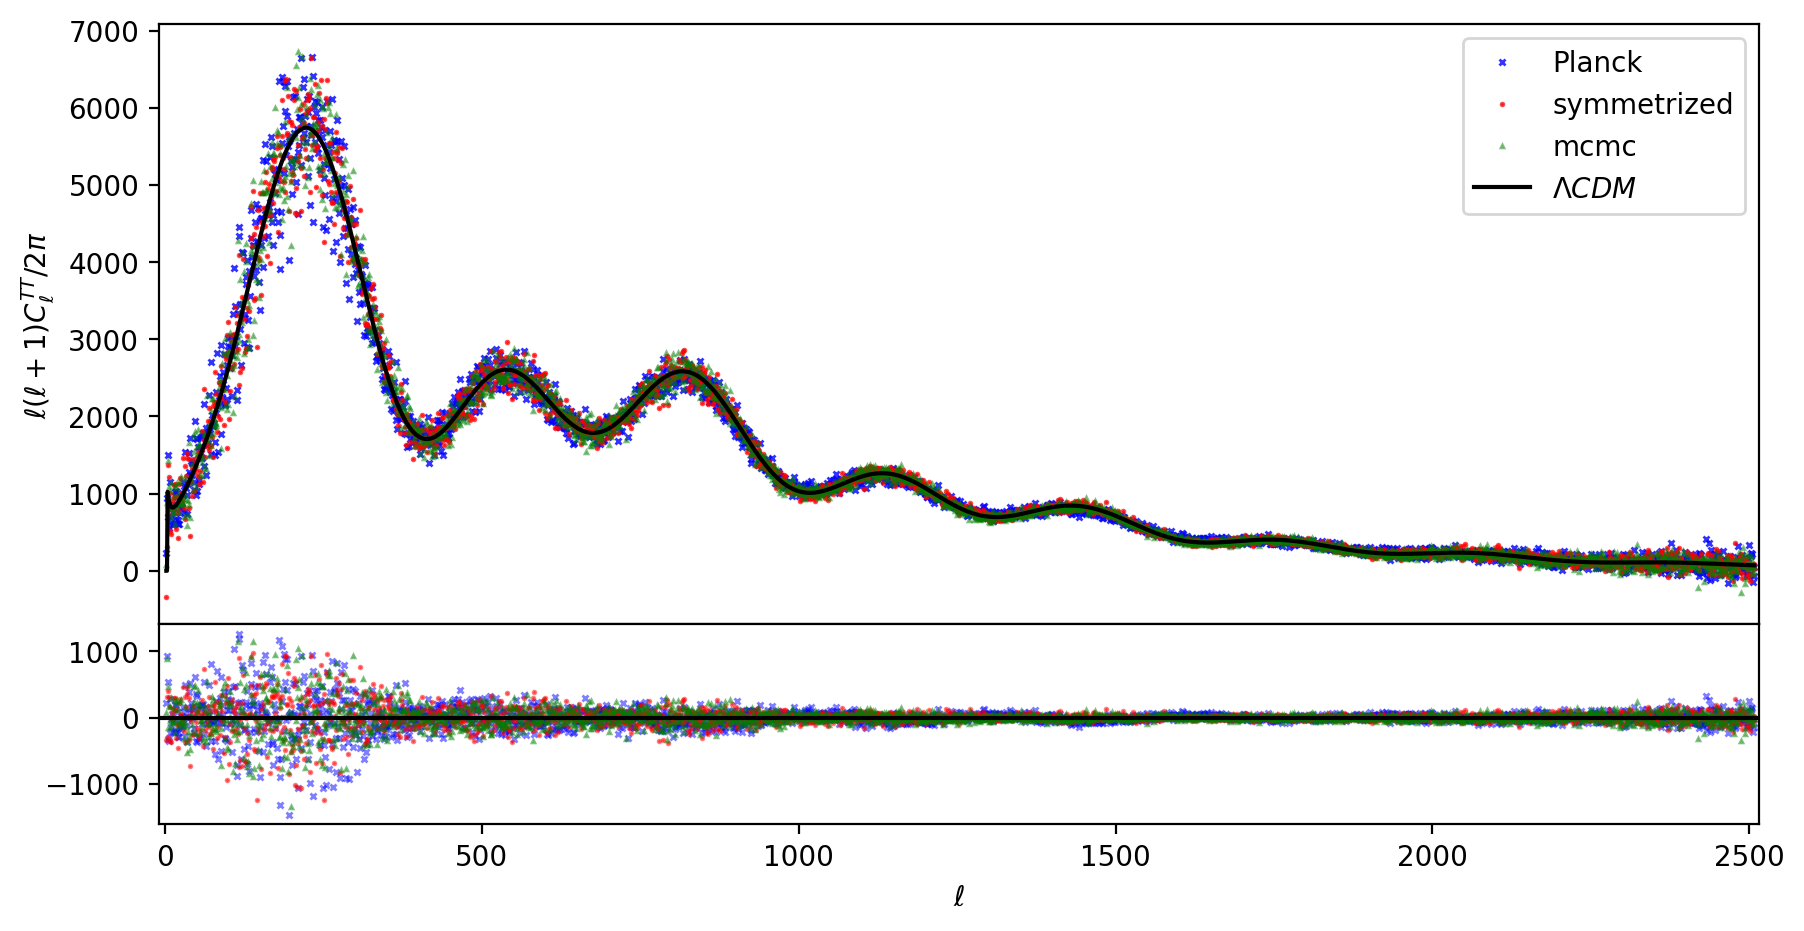

In [11]:
fig = plt.figure(figsize=(10,5))
frame1 = fig.add_axes((.1,.3,.8,.6))

plt.plot(round_ls_Pl_TT,dl_Planck_TT, marker='x', color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.8)
plt.plot(round_ls_Pl_TT,dlstt_symmetrized, marker='o' , color='red', label='symmetrized', linestyle='None', markersize=1, alpha = 0.7)
plt.plot(round_ls_Pl_TT,dlstt_mcmc, marker='^', color='green', label='mcmc', linestyle='None', markersize=1, alpha = 0.5)
plt.plot(round_ls_Pl_TT,dlstt, color='black', label='$\Lambda CDM$', linestyle='-')
plt.xlabel('$\ell$')
plt.ylabel('$\ell(\ell+1)C_{\ell}^{TT}/2\pi$')
plt.xticks(fontsize=1)
plt.legend()

# Residual plot
frame2 = fig.add_axes((.1,.1,.8,.2), sharex=frame1) 

diff_planck = []
for i, j in zip(dl_Planck_TT,dlstt):
    diff_planck.append(i - j)
diff_symm = []
for i, j in zip(dlstt_symmetrized,dlstt):
    diff_symm.append(i - j) #int because i outputs a .0 number, not integer
diff_mcmc = []
for i, j in zip(dlstt_mcmc,dlstt):
    diff_mcmc.append(i - j)

plt.plot(round_ls_Pl_TT, diff_planck, marker='x' , color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.5)
plt.plot(round_ls_Pl_TT, diff_symm, marker='o' , color='red', label='symmetrized', linestyle='None', markersize=1, alpha = 0.5)
plt.plot(round_ls_Pl_TT, diff_mcmc, marker='^' , color='green', label='mcmc', linestyle='None', markersize=1, alpha = 0.5)
frame2.axhline(y=0, color='black', linestyle='-')
plt.xlabel('$\ell$')

plt.xlim(-10,2515)

In [12]:
#Read Covariance matrix (TE case)
cov_matx_dlte_mcmc = np.loadtxt('./simulated_data/dlste_cov_matx(mcmc).csv', delimiter=",")
dlste_mcmc = add_noise_spectrum(Power_spectra.te, cov_matx_dlte_mcmc, seed0)

(-10.0, 2000.0)

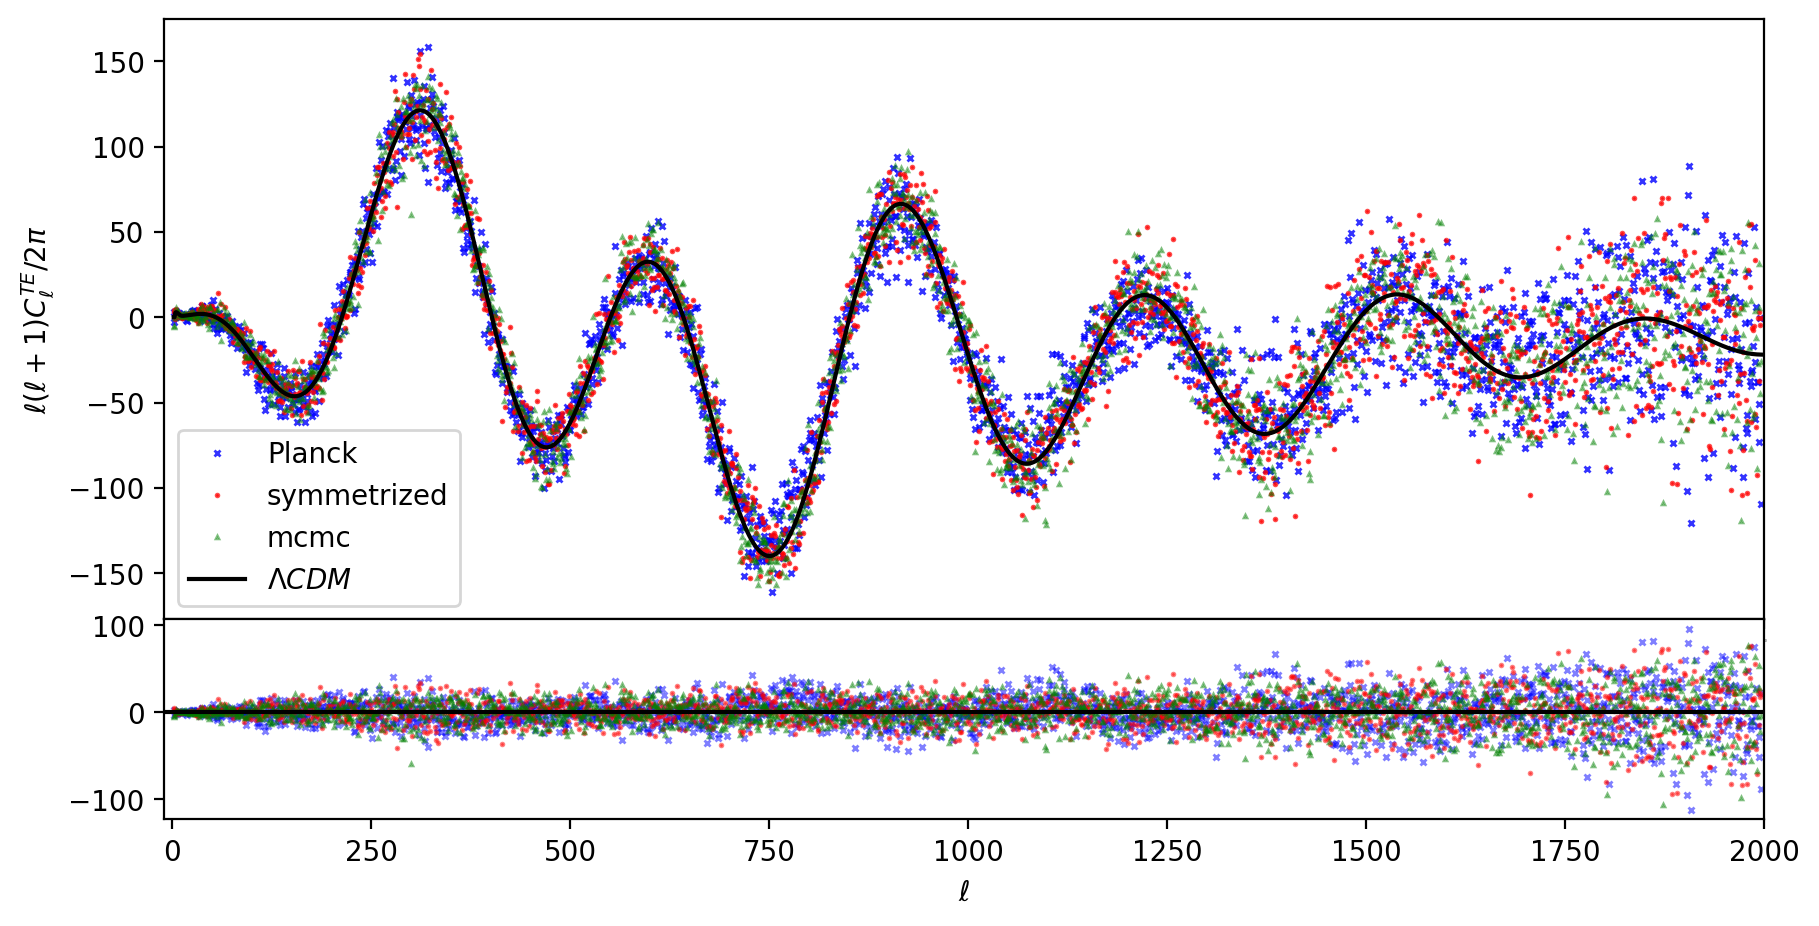

In [13]:
fig = plt.figure(figsize=(10,5))
frame1 = fig.add_axes((.1,.3,.8,.6))

plt.plot(round_ls_Pl_TE,dl_Planck_TE, marker='x', color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.8)
plt.plot(round_ls_Pl_TE,dlste_symmetrized, marker='o' , color='red', label='symmetrized', linestyle='None', markersize=1, alpha = 0.7)
plt.plot(round_ls_Pl_TE,dlste_mcmc, marker='^', color='green', label='mcmc', linestyle='None', markersize=1, alpha = 0.5)
plt.plot(round_ls_Pl_TE,dlste, color='black', label='$\Lambda CDM$', linestyle='-')
plt.xlabel('$\ell$')
plt.ylabel('$\ell(\ell+1)C_{\ell}^{TE}/2\pi$')
plt.xticks(fontsize=1)
plt.legend()

# Residual plot
frame2 = fig.add_axes((.1,.1,.8,.2), sharex=frame1) 

diff_planck = []
for i, j in zip(dl_Planck_TE, dlste):
    diff_planck.append(i - j)
diff_symm = []
for i, j in zip(dlste_symmetrized, dlste):
    diff_symm.append(i - j) #int because i outputs a .0 number, not integer
diff_mcmc = []
for i, j in zip(dlste_mcmc,dlste):
    diff_mcmc.append(i - j)

plt.plot(round_ls_Pl_TE, diff_planck, marker='x' , color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.5)
plt.plot(round_ls_Pl_TE, diff_symm, marker='o' , color='red', label='symmetrized', linestyle='None', markersize=1, alpha = 0.5)
plt.plot(round_ls_Pl_TE, diff_mcmc, marker='^' , color='green', label='mcmc', linestyle='None', markersize=1, alpha = 0.5)
frame2.axhline(y=0, color='black', linestyle='-')
plt.xlabel('$\ell$')

plt.xlim(-10,2000)

In [14]:
#Read Covariance matrix (EE case)
cov_matx_dlee_mcmc = np.loadtxt('./simulated_data/dlsee_cov_matx(mcmc).csv', delimiter=",")
dlsee_mcmc = add_noise_spectrum(Power_spectra.ee, cov_matx_dlee_mcmc, seed0)

(-10.0, 2000.0)

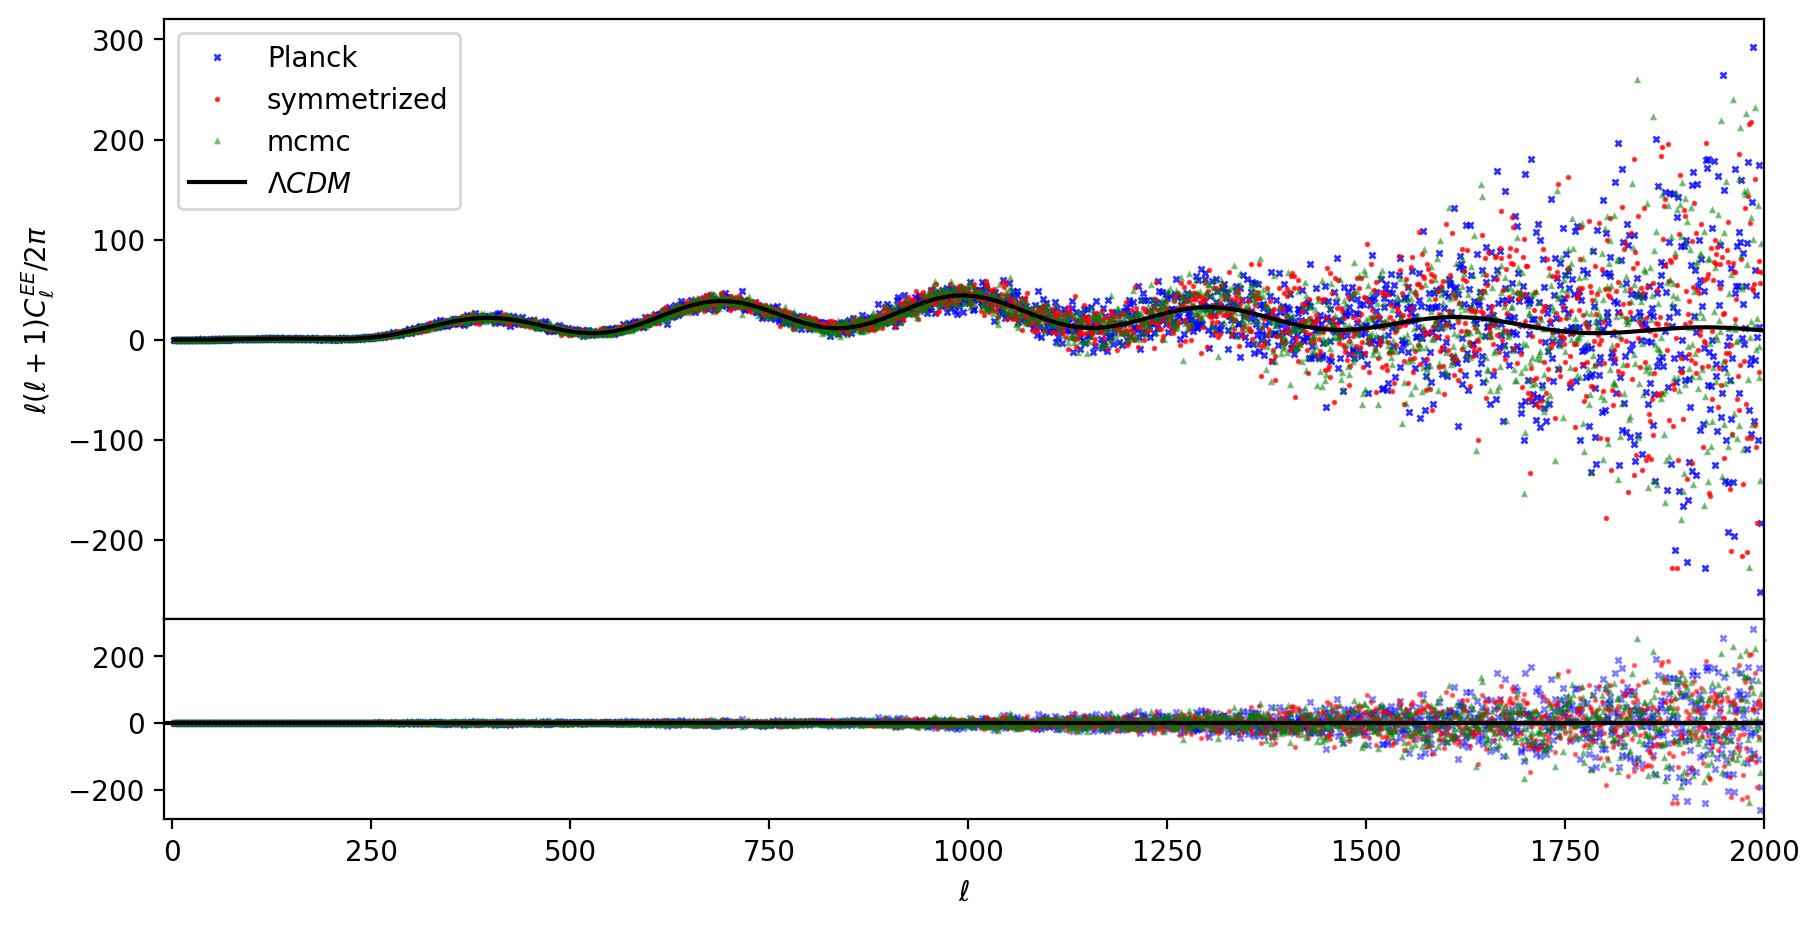

In [15]:
fig = plt.figure(figsize=(10,5))
frame1 = fig.add_axes((.1,.3,.8,.6))

plt.plot(round_ls_Pl_EE,dl_Planck_EE, marker='x', color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.8)
plt.plot(round_ls_Pl_EE,dlsee_symmetrized, marker='o' , color='red', label='symmetrized', linestyle='None', markersize=1, alpha = 0.7)
plt.plot(round_ls_Pl_EE,dlsee_mcmc, marker='^', color='green', label='mcmc', linestyle='None', markersize=1, alpha = 0.5)
plt.plot(round_ls_Pl_EE,dlsee, color='black', label='$\Lambda CDM$', linestyle='-')
plt.xlabel('$\ell$')
plt.ylabel('$\ell(\ell+1)C_{\ell}^{EE}/2\pi$')
plt.xticks(fontsize=1)
plt.legend()

# Residual plot
frame2 = fig.add_axes((.1,.1,.8,.2), sharex=frame1) 

diff_planck = []
for i, j in zip(dl_Planck_EE, dlsee):
    diff_planck.append(i - j)
diff_symm = []
for i, j in zip(dlsee_symmetrized, dlsee):
    diff_symm.append(i - j) #int because i outputs a .0 number, not integer
diff_mcmc = []
for i, j in zip(dlsee_mcmc,dlsee):
    diff_mcmc.append(i - j)

plt.plot(round_ls_Pl_EE, diff_planck, marker='x' , color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.5)
plt.plot(round_ls_Pl_EE, diff_symm, marker='o' , color='red', label='symmetrized', linestyle='None', markersize=1, alpha = 0.5)
plt.plot(round_ls_Pl_EE, diff_mcmc, marker='^' , color='green', label='mcmc', linestyle='None', markersize=1, alpha = 0.5)
frame2.axhline(y=0, color='black', linestyle='-')
plt.xlabel('$\ell$')

plt.xlim(-10,2000)

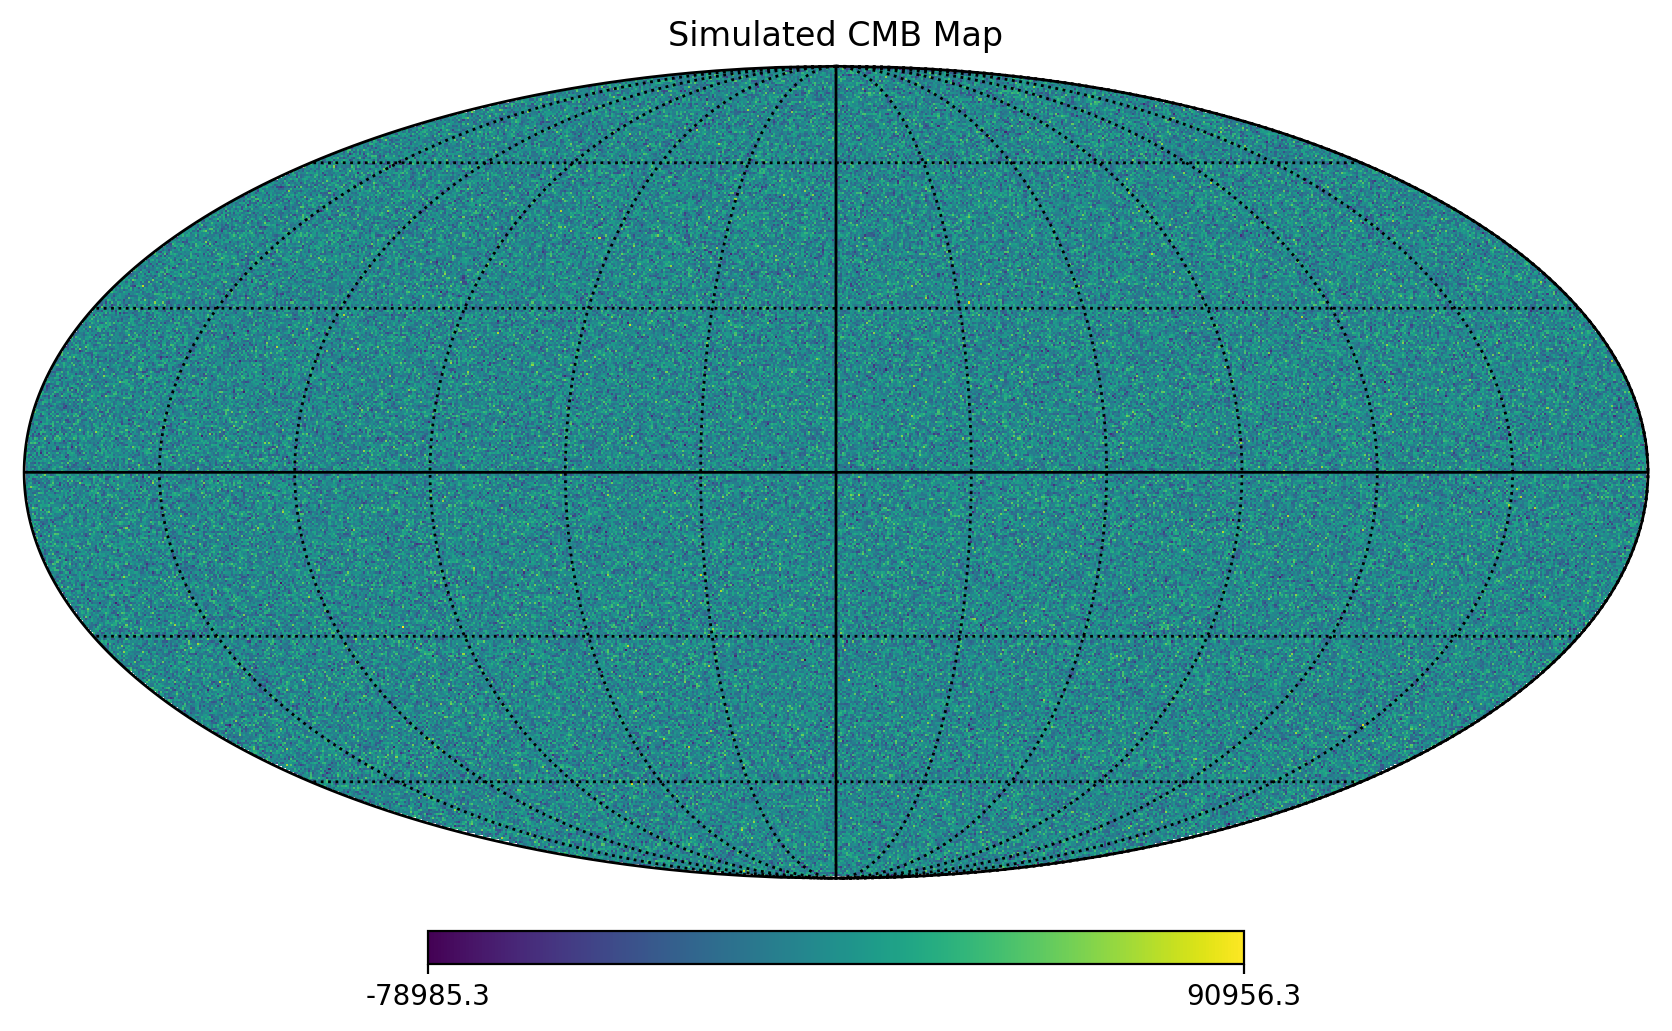

In [18]:
from CMBFeatureNet import generate_cmb_map

# Call the function to generate and visualize the CMB map
cmb_map = generate_cmb_map(dlstt_mcmc, nside=2048)